# Hypothesis Testing

This week, we will go through some examples on hypothesis testing by examining different datasets. In addition, we'll also have some interactive exercises. 

![](https://s3.amazonaws.com/libapps/accounts/73970/images/descriptive_and_inferential.JPG)

In [ ]:
from google.colab import drive
drive.mount("./drive", force_remount=True)

path_prefix = "./drive/My Drive/"

Mounted at ./drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# the library to perform statistical tests
from scipy import stats
from scipy import special
from os.path import join
import seaborn as sns

%matplotlib inline

### An Experiment on The Effect of Drugs

A neurologist is testing the effect of a drug on response time by injecting 100 rats a unit dose of drug, subjecting each to a neurological stimulus and recording their response time. The neurologist knows that **the mean response time for rats not injected with te drug is 1.2 seconds**. **The mean of the 100 injected rats' response time is 1.05 seconds with a sample standard deviation of 0.5 seconds**. Do you think that the drug has an effect on the response time?

*Please open the notebook and follow the lead of your TA to answer this question.*

#### Populations and samples

- A **population** includes all of the elements from a set of data, i.e. contains all members of a specified group.
- A **sample** consists one or more observations drawn from the population.

![](https://online.stat.psu.edu/stat200/sites/stat200/files/inline-images/InferenceGraphicSU17.png)



#### Plotting a Probability Density Function

Firstly, let's plot how a **normal distribution** look like. In order to do that we need to determine the values for mean and std.


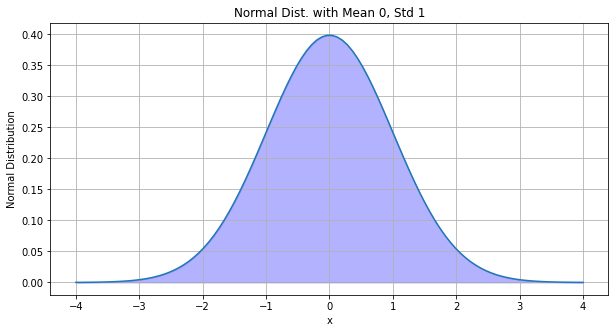

In [ ]:
# mean and std values from the sample
mean = 0
std = 1
n = 100
offset = 4*std

# the x-axis ticks of the plot
# generates 100 equally separated ticks
x = np.linspace(mean-offset, mean+offset, n)

# probability density function
# of the given normal dist.
y = stats.norm.pdf(x, mean, std)

plt.figure(figsize=(10, 5))
plt.plot(x,y)
# put grids on the figure
plt.grid()
plt.xlabel("x")
plt.ylabel("Normal Distribution")
# filling the area below the line
plt.fill_between(x, y, alpha=0.3, color="b")
plt.title(f"Normal Dist. with Mean {mean}, Std {std}")
plt.show()

#### Sampling Distribution STD

Here, we take a sample from the population and measure the response time and obtain sample statistics. In order to assess the extremeness of the drugged sample, we need to evalute it in the sampling distribution.

Due to the Centra Limit Theorem, we know that the sampling distribution of mean response times will approximate to a normal distribution with mean set to population mean ($\mu$) and std to $\sigma /\sqrt{N}$, where $\sigma$ is population std and N is the sample size.

We can use the sample standard deviation to estimate the sampling distribution std with the formula below. Although, we do not know the population std, we can use the sample std as an estimator because of the fair sample size.

$\large{\sigma_{sampling \, dist.} = \frac{\sigma_{population}}{\sqrt{sample \; size}}}$

Now, let's first find the std of sampling distribution and plot it.

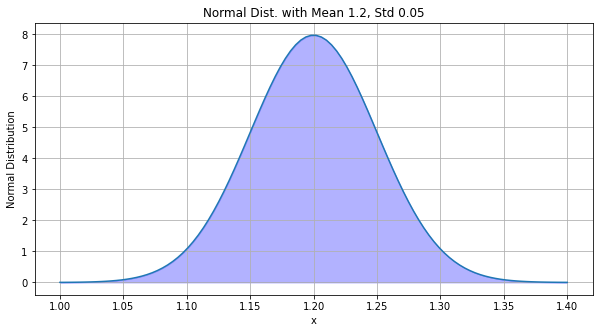

In [ ]:
# mean and std values from the sample
n = 100
mean = 1.2
std = 0.5 / np.sqrt(n)
offset = 4*std

# the x-axis ticks of the plot
# generates 100 equally separated ticks
x = np.linspace(mean - offset, mean + offset, n)

# probability density function
# of the given normal dist.
y = stats.norm.pdf(x, mean, std)

plt.figure(figsize=(10, 5))
plt.plot(x,y)
# put grids on the figure
plt.grid()
plt.xlabel("x")
plt.ylabel("Normal Distribution")
plt.fill_between(x, y, alpha=0.3, color="b")
plt.title(f"Normal Dist. with Mean {mean}, Std {std}")
plt.show()

#### Z-Score

Now we need a method to compare the drugged sample with the sampling distribution mean and tell how significantly distant the means are from each other. 

We can use the **z-scores** and find how many standard deviations away the sample mean (drugged rats) is from the population mean. To calculate the z-scores, you can use the formula below.

$\Large{Z = \frac{\bar{x}_{sample} - \mu_{sampling \, dist.}}{\sigma_{sampling \, dist.}}}$

So now, let's first calculate the z-score and find out how many standard deviations away our sample mean is.

In [ ]:
# mean and std values from the sample
n = 100
mean = 1.2
std = 0.5 / np.sqrt(n)

# sample mean (drugged rats)
sample_mean = 1.05

# calculating the z-score
z_score = (sample_mean - mean) / std

print("z-score: {}".format(z_score))

z-score: -2.9999999999999982


#### Locating The Sample

With the z-score at hand, we can further display how distant our sample mean is from the population mean. 

On top of the derived plot above, put a vertical line corresponding to **population_mean - (z-score*population_std)**, so that we can observe where the sample mean is located.

In matplotlib you can use `plt.axvline(location_on_x_axis, color="red")` function to put a vertical line on the plot. You may check this [link](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.axvline.html) to learn more about it.

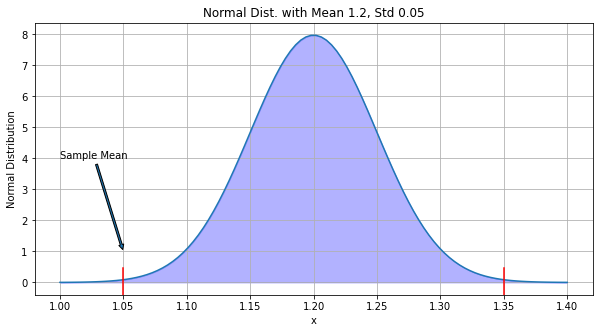

In [ ]:
# mean and std values from the sample
n = 100
mean = 1.2
std = 0.5 / np.sqrt(n)
offset = 4*std

# sample mean (drugged rats)
sample_mean = 1.05

# calculating the z-score
z_score = (sample_mean - mean) / std

# the x-axis ticks of the plot
# generates 100 equally separated ticks
x = np.linspace(mean - offset, mean + offset, n)

# probability density function
# of the given normal dist.
y = stats.norm.pdf(x,mean,std)

plt.figure(figsize=(10, 5))
plt.plot(x,y)
# put grids on the figure
plt.grid()
plt.xlabel('x')
plt.ylabel('Normal Distribution')
plt.fill_between(x, y, alpha=0.3, color='b')
# display the z-score locations
plt.axvline(mean - z_score*std, ymax=0.1, color="red")
plt.axvline(mean + z_score*std, ymax=0.1, color="red")
# annotate the sample mean
plt.annotate(
    "Sample Mean", # annotation text
    xy=(mean + z_score*std, 1), # annotated coordinate
    xytext=(1, 4), # annotation text coordinate
    arrowprops={"arrowstyle": "simple"}) # arrow style
plt.title('Normal Dist. with Mean {}, Std {}'.format(mean, std))
plt.show()

![](https://mindcul.com/wp-content/uploads/2019/03/68-95-997.png)

At this point, we know what our z-score is. We also found out that the sample mean is _z-score_ standard deviation away from the population mean. **So what is the propability of getting a result this extreme?** We can utilize the z-table to obtain the target probability value. For instance, the figure above shows that the area which is one standard deviation away from the mean has a 0.68 probability. So we can compute the probability of the area we obtained with the z-score.



In [ ]:
# calculating the probability
# multiply by 2 to consider both ends
prob = 2*stats.norm.cdf(z_score)

print(f"probability: {prob}")

probability: 0.0026997960632602026


In [ ]:
'''

p-value(0.0027) <= alfa(0.05) --> Reject the null hyphothesis
p-value(0.0027) > alfa(0.05) --> Not reject the null hyphothesis

'''

Based on the obtained results, what is your take on the first question? Do you think that the drug has an effect on the response time?

### Notes on Hypothesis Testing

> Hypothesis tests use data from a sample to make an inference about the value of a population parameter.


#### The Structure of a Hypothesis Test

1. Determine the hypotheses
  - **Null Hypothesis ($\large{H_0}$)**: Commonly accepted as the current fact, the hypothesis that sample observations result purely from chance.
  - **Alternative Hypothesis ($\large{H_A}$)**: The main purpose of the study, the hypothesis that you claim.

2. Collect and summarize the data into a **test statistic**.

  - Data and hypothesis determines the test type.
  - Once we have the two hypotheses, we’ll use the data to test which hypothesis we should believe.

3. Use the test statistic to determine the **p-value**.

4. The result is statistically significant if the p-value is less than or equal to the **level of significance ($\large{\alpha}$)**.

  - "Significance" is usually defined in terms of **a probability threshold $\alpha$** (generally set to 0.05).
  - We deem a particular result significant if the probability of obtaining that result under the null distribution is less than $\alpha$. This probability is known as the **p-value**.
  - p-values evaluate how well the sample data support that the null hypothesis is true.
  - The significance level, $\alpha$, is the probability of rejecting the null hypothesis when it is true.

If the obtained p-value is less than or equal to the significance value, the null hypothesis is rejected, otherwise we **fail to reject the null hypothesis.**

<img width="400" height="350" src="https://i.pinimg.com/originals/84/c6/7e/84c67e1a25bebdd3afad543c6bf79f89.jpg"></img>


#### A Small Example on Hypotheses

**Question**:  Do participants lose weight following a weight-loss intervention?

Data were collected from one group of participants before and after a weight-loss intervention. Data were paired by participant.  Assuming that **$x_1$ is an individual's weight before the intervention** and **$x_2$ is their weight at the end of the study**, **if they lost weight then $x_1 - x_2$ would be a positive number** (i.e., greater than 0). Thus, this is a right-tailed test. Because we are testing their mean difference, the parameter that we should write in our hypotheses is $\mu_d$ **where $\mu_d$ is the mean weight change** (before-after) in the population.

Our hypotheses are:

- $\large H_0: \mu_d = 0$
- $\large H_A: \mu_d > 0$
 

[source](https://online.stat.psu.edu/stat200/lesson/5/5.2/5.2.1)

#### Test Types

- In a **one-tailed hypothesis test**, we choose one direction for our alternative hypothesis: we either hypothesize that the test statistic is “significantly big”, or that the test statistic is “significantly small”.

- In a **two-tailed hypothesis test**, our alternative hypothesis encompasses both directions: we hypothesize that the test statistic is simply different from the predicted value.

![](https://www.fromthegenesis.com/wp-content/uploads/2018/06/Types-of-Hypothesis-Tests.jpg)



#### Error Types

When conducting a hypothesis test there are two possible decisions: reject the null hypothesis or fail to reject the null hypothesis. You should remember though, hypothesis testing uses data from a sample to make an inference about a population. When conducting a hypothesis test we do not know the population parameters. In most cases, we don't know if our inference is correct or incorrect.

||$H_0$ is true|$H_0$ is false|
|---|---|---|
|Reject $H_0$|**Type I Error**|Correct Decision|
|Fail to reject $H_0$|Correct Decision|**Type II Error**|

In terms of a courtroom scenario:

> Type I Error: Convicting an innocent defendant.

> Type II Error: Acquitting a criminal.

Lower $\alpha$ levels mean that smaller p-values are needed to reject the null hypothesis; this makes it more difficult to reject the null hypothesis, but this also reduces the probability of committing a Type I error.

### Visualizing Students' Performance

In "StudentsPerformance.csv", each row corresponds to a student with associated exam scores. In addition, we also have the ethnicity and the education level of their parents.

In [ ]:
filename = "StudentsPerformance.csv"

df = pd.read_csv(filename)

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Now, let's check if there is any significant difference between the students who completed the preparation course and those who did not.  
For this exercise, our focus is on reading scores.

In [ ]:
test_type = "reading score"

comp_studs = df[df["test preparation course"] == "completed"][test_type]  # completed students
none_studs = df[df["test preparation course"] == "none"][test_type]       # none students

In [ ]:
print(f"mean score of students who completed the course: {comp_studs.mean():.2f}")

mean score of students who completed the course: 73.89


In [ ]:
print(f"mean score of students who did not complete the course: {none_studs.mean():.2f}")

mean score of students who did not complete the course: 66.53


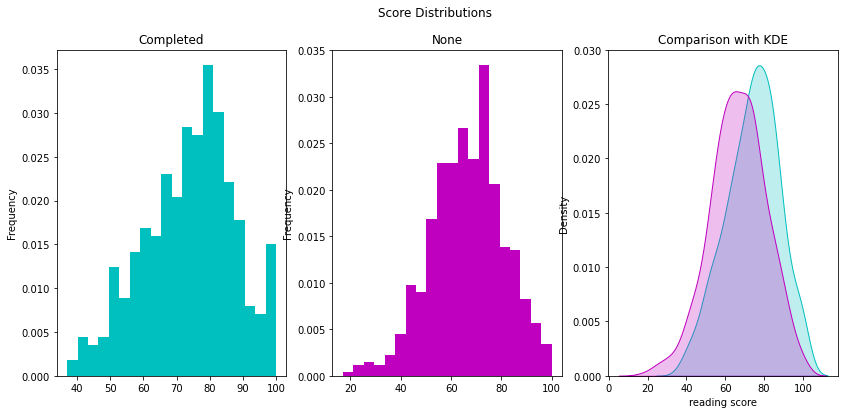

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14,6))  # a figure with 1 row and 3 columns
                                              # ax variable stores a list with 3 elements
                                              # each element in ax correspons to chart
        
comp_studs.plot(kind="hist", ax=ax[0], bins=20, label="completed", color="c", density=True)
ax[0].set_title("Completed")

none_studs.plot(kind="hist", ax=ax[1], bins=20, label="none", color="m", density=True)
ax[1].set_title("None")

sns.kdeplot(comp_studs, shade=True, label="completed students", ax=ax[2], color="c")
sns.kdeplot(none_studs, shade=True, label="none students", ax=ax[2], color="m")
ax[2].set_title("Comparison with KDE")

plt.suptitle("Score Distributions")
plt.show()

From the figure above, we can see that the students who took the course obtained better results on average compared to the one who did not.  
Now, let's show this difference statistically by applying a significance test.

### T-Test

It is used to determine if there is a significant difference between the means of two groups. 

- **One-Sample T-test**
 - The One-Sample T-test determines whether the sample mean is statistically different from a known or hypothesised population mean.
- **Two-Sample T-test**
 - Determines whether the average difference between two groups is really significant or if it is due to random chance.

In [ ]:
rand_dist = np.random.normal(loc=10, scale=3, size=100)  # a normal dist with mean 10 and std 3

In [ ]:
rand_dist.mean()

10.039387916716693

In [ ]:
# let's apply one-sample t-test
stats.ttest_1samp(rand_dist, 10)

Ttest_1sampResult(statistic=0.1421365293536569, pvalue=0.8872610244615655)

In [ ]:
# test score (statistic) sign gives type of test type
# here, we have a negative test score which tells us that
# the data we have has a mean less than 11
stats.ttest_1samp(rand_dist, 11)

Ttest_1sampResult(statistic=-3.4664963002526106, pvalue=0.0007814264330002979)

In [ ]:
# in this case, we have a positive test score
# which means we have a mean greater than 9
stats.ttest_1samp(rand_dist, 9)

Ttest_1sampResult(statistic=3.7507693589599245, pvalue=0.0002970679656628108)

Now, let's get back to the students data set. We can apply two-sample t-test to samples drawn from students data set.

In [ ]:
stats.ttest_ind(none_studs, comp_studs, equal_var=False)  # since we have not equal variances

Ttest_indResult(statistic=-8.004132353965, pvalue=4.388808024290594e-15)

If we set the significance level as 0.05, we can reject the null hypothesis. In addition, the test score is positive which indicates that the mean score for students who completed the course is higher than those who did not.

### Exercise: Chi Square Test exercise

Instructions

- Once you are assigned to a breakout room, discuss among yourselves to decide who will be sharing the screen to collectively develop a solution. Actively participate in the group discussion.
- For your questions, you may use the `request help` button on the zoom menu.

The Chi-Squared test is is a statistical test applied to sets of categorical data to evaluate how likely it is that any observed difference between the sets arose by chance.

In [ ]:
filename = "happiness.csv"

df_c = pd.read_csv(join(path_prefix, filename))

In [ ]:
df_c.head()

,gender,status
0,male,happy
1,female,very happy
2,female,neutral
3,male,unhappy
4,male,very unhappy


##### Calculating the Cross Tabulation Table

- Add the `happiness.csv` file as a shortcut to your drive.

- Calculate the cross tabulation between attributes `gender` and `status`. The result should look the output below. *Hint: You may use the [crosstab](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html) function to obtain the required dataframe.*

  ![](https://i.ibb.co/gvPQCLh/kek.png)

- Plot a grouped bar chart in which happiness status counts are displayed by gender by utilizing the resulting cross tabulation dataframe.

The result should look like the figure below.

![](https://i.ibb.co/f19DDWc/pp-1.png)

In [ ]:
# your code

In [ ]:
# solution 1 - calculate the cross tabulation

crosstab_df = pd.crosstab(df_c["gender"], df_c["status"])
crosstab_df

status,happy,neutral,unhappy,very happy,very unhappy
gender,,,,,
female,7,14,10,12,6
male,11,8,11,10,11


In [ ]:
# solution 2 - calculate the cross tabulation
crosstab_df = df_c.groupby(['gender', 'status']).size().unstack()
crosstab_df

status,happy,neutral,unhappy,very happy,very unhappy
gender,,,,,
female,7,14,10,12,6
male,11,8,11,10,11


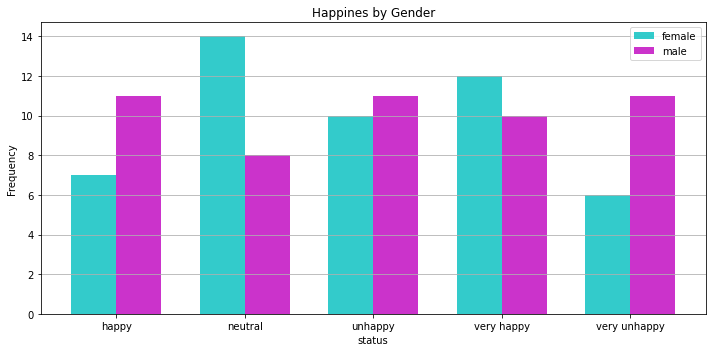

In [ ]:
# solution - option 1

female = crosstab_df.loc["female"]
male = crosstab_df.loc["male"]

fig, ax = plt.subplots(1, 1, figsize=(10,5))

index = np.arange(crosstab_df.columns.shape[0])
bar_width = 0.35
opacity = 0.8
 
rects1 = plt.bar(index, crosstab_df.loc["female"], bar_width,
    alpha=opacity,
    color='c',
    label='female')
 
rects2 = plt.bar(index + bar_width, crosstab_df.loc["male"], bar_width,
    alpha=opacity,
    color='m',
    label='male')
 
plt.ylabel("Frequency")
plt.title("Happines by Gender")
plt.grid(axis="y")
plt.xlabel('status')
plt.xticks(index + (bar_width / 2), crosstab_df.columns)
plt.legend()
 
plt.tight_layout()
plt.show()

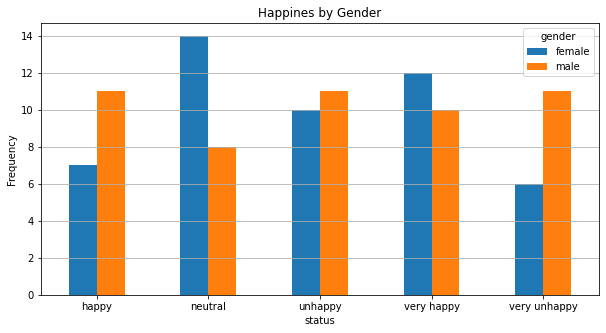

In [ ]:
# solution - option 2

ax = crosstab_df.T.plot.bar(figsize=(10, 5), rot=0)
ax.set_ylabel("Frequency")
ax.set_title("Happines by Gender")
ax.grid(axis="y");

##### Performing the Test

In the second part of the exercise, you are going to perform the test, with the help of [`chi2_contingency`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html) from scipy.

- Perform the test and based on the obtained values state your verdict with $\alpha$ (level of significance) set to 0.05.


In [ ]:
# your code

In [ ]:
# solution

alpha = 0.05
chi2_test_stat, p_value, dof, expected_freqs = stats.chi2_contingency(crosstab_df)

result = "independet" if p_value > alpha else "not independent"
print(f"Gender and happiness status are {result}")

Gender and happiness status are independet
